## Load the model

In [10]:
import torch
import nn4n.nn
device = torch.device("cuda" if torch.cuda.is_available() else "mps")

T, D = 200, 100

num_neuron = 512

model_cfg = {
            "input_dim":    D,
            "hidden_dim":   num_neuron,
            'output_dim':   D,
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [11]:
# Load the model in pth file
model_path = "../../model/2TS_b.pth"
rnn.load_state_dict(torch.load(model_path, map_location=device))

<All keys matched successfully>

## Create test input

In [1]:
import numpy as np
import sys
sys.path.append('..')
from rtgym.utils.masking import Masking
from matplotlib import pyplot as plt
from func import plt_hs, time_analysis
from scipy.ndimage import gaussian_filter

test_B, T, D = 100, 200, 100
temp_reso = 10

### 1) Replace two events with noise

In [49]:
signal_amp_mu, signal_amp_sigma = 4.0, 0.5
sensory_profile = {
                    "time": {
                            "sigma":  0.5, # sigma of Gaussian noise
                            "ssigma": 0.2, # smoothing sigma of Gaussian noise (in sec)
                            "bias":   signal_amp_mu,   # mean of Gaussian noise (comparable to signal amplitude)
                            },
                    }

# Generate random Gaussian noise
noisy_res = np.random.normal(sensory_profile['time']['bias'], sensory_profile['time']['sigma'], (test_B, T, D)) 
# Smooth out the temporal profile
from scipy.ndimage import gaussian_filter
time_res = gaussian_filter(noisy_res, sigma=(0, sensory_profile['time']['sigma'], 0)) 
print(time_res.shape)  # Should be (B, T, D)

(100, 200, 100)


In [50]:
# Mask the input
# This mask ratio is the same as place cells in square room, not other time cells simulation.
mask = Masking(
                m_max=0.4,    # Maximum masking ratio
                m_min=0.2,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )

### 2) Present 1 event

In [75]:
x = np.linspace(0, 8, 100)
signal_amp_mu, signal_amp_sigma = 4.0, 0.5
y = np.exp(-(x - signal_amp_mu)**2 / (2 * signal_amp_sigma**2))

# Fix the random seed for reproducibility
rng = np.random.default_rng(seed=42)
temp_event_1 = rng.normal(loc=signal_amp_mu, scale=signal_amp_sigma, size=(D,))

# Generate the first temporal event with shape n_channels, Select fixed random number from a normal distribution
event_1_onset, event_1_end = 2.5, 3.0

# Make the onset and end time randomly and convert to indices (sigma=0.2s)
event_1_onsets = np.random.normal(event_1_onset*temp_reso, 0.2*temp_reso, (test_B, D)).astype(int)
event_1_ends   = np.random.normal(event_1_end*temp_reso,   0.2*temp_reso, (test_B, D)).astype(int)

sensory_profile = {
                    "time": {
                            "sigma":       0.5,    # sigma of Gaussian noise
                            "ssigma":      0.2,    # smoothing sigma of Gaussian noise (in sec)
                            "bias":        0,  # mean of Gaussian noise (comparable to signal amplitude)
                            },
                    }

# Generate random Gaussian noise
noisy_res = np.random.normal(sensory_profile['time']['bias'], sensory_profile['time']['sigma'], (test_B, T, D)) 
# Replace the noisy_res values with the temporal events at the specified onsets and ends
for b in range(test_B):
    for d in range(D):
        noisy_res[b, event_1_onsets[b, d]:event_1_ends[b, d], d] = temp_event_1[d]
# Smooth out the temporal profile
time_res = gaussian_filter(noisy_res, sigma=(0, sensory_profile['time']['sigma'], 0)) 
print(time_res.shape)  # Should be (B, T, D)

(100, 200, 100)


In [76]:
mask = Masking(
                m_max=0.3,    # Maximum masking ratio
                m_min=0.1,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )

### 3) Present 2 events

In [81]:
x = np.linspace(0, 8, 100)
signal_amp_mu, signal_amp_sigma = 4.0, 0.5
y = np.exp(-(x - signal_amp_mu)**2 / (2 * signal_amp_sigma**2))

# Fix the random seed for reproducibility
rng = np.random.default_rng(seed=42)
temp_event_1 = rng.normal(loc=signal_amp_mu, scale=signal_amp_sigma, size=(D,))
temp_event_2 = rng.normal(loc=signal_amp_mu, scale=signal_amp_sigma, size=(D,))

# Generate the first temporal event with shape n_channels, Select fixed random number from a normal distribution
event_1_onset, event_1_end = 2.5, 3.0
event_2_onset, event_2_end = 17.5, 18.0

# Make the onset and end time randomly and convert to indices (sigma=0.2s)
event_1_onsets = np.random.normal(event_1_onset*temp_reso, 0.2*temp_reso, (test_B, D)).astype(int)
event_1_ends   = np.random.normal(event_1_end*temp_reso,   0.2*temp_reso, (test_B, D)).astype(int)
event_2_onsets = np.random.normal(event_2_onset*temp_reso, 0.2*temp_reso, (test_B, D)).astype(int)
event_2_ends   = np.random.normal(event_2_end*temp_reso,   0.2*temp_reso, (test_B, D)).astype(int)


sensory_profile = {
                    "time": {
                            "sigma":       0.5,    # sigma of Gaussian noise
                            "ssigma":      0.2,    # smoothing sigma of Gaussian noise (in sec)
                            "bias":        0,  # mean of Gaussian noise (comparable to signal amplitude)
                            },
                    }

# Generate random Gaussian noise
noisy_res = np.random.normal(sensory_profile['time']['bias'], sensory_profile['time']['sigma'], (test_B, T, D)) 
# Replace the noisy_res values with the temporal events at the specified onsets and ends
for b in range(test_B):
    for d in range(D):
        noisy_res[b, event_1_onsets[b, d]:event_1_ends[b, d], d] = temp_event_1[d]
        noisy_res[b, event_2_onsets[b, d]:event_2_ends[b, d], d] = temp_event_2[d]
# Smooth out the temporal profile
time_res = gaussian_filter(noisy_res, sigma=(0, sensory_profile['time']['sigma'], 0)) 
print(time_res.shape)  # Should be (B, T, D)

(100, 200, 100)


## Visualise test input

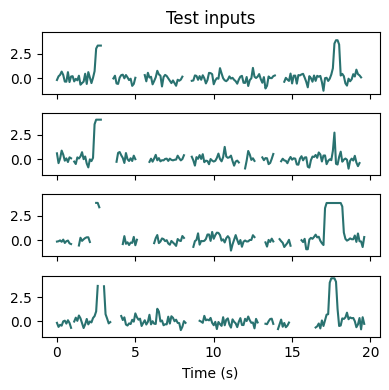

In [82]:
test_inputs = mask.mask(time_res).numpy()

fig, ax = plt.subplots(4, 1, figsize=(4, 4), sharex=True, sharey=True)
for i, channel in enumerate(range(5, 9)):
    ax[i].plot(np.arange(test_inputs.shape[1]) / 10, 
                # Replace the test_inputs 0 with nan
                np.where(test_inputs[0, :, channel] == 0, np.nan, test_inputs[0, :, channel]),
                label=f'{i+1}', color='#297270')
ax[0].set_title('Test inputs')
ax[-1].set_xlabel('Time (s)')
plt.tight_layout()

## Test the model

In [83]:
# Test the model with random input
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(torch.tensor(test_inputs, dtype=torch.float32).to(device))

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

test outputs: <class 'numpy.ndarray'> (100, 200, 100)
hidden states: <class 'numpy.ndarray'> (100, 200, 512)


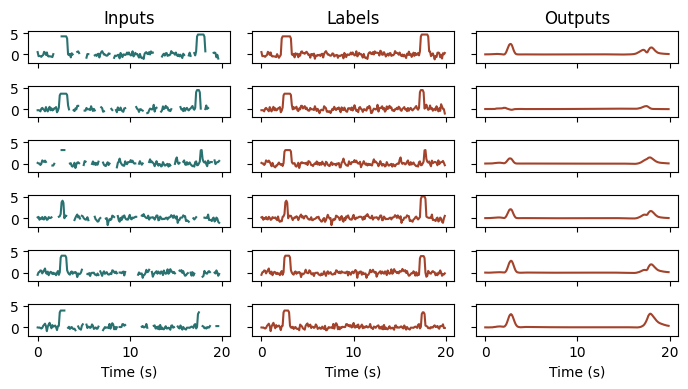

In [84]:
fig, ax = plt.subplots(6, 3, figsize=(7, 4), sharex=True, sharey=True)
# Randomly sample a few channels to plots
rand_D = np.random.choice(D, size=6, replace=False)
for i, channel in enumerate(rand_D):
    
    ax[i][0].plot(np.arange(test_inputs.shape[1]) / 10, 
                # Replace the test_inputs 0 with nan
                np.where(test_inputs[0, :, channel] == 0, np.nan, test_inputs[0, :, channel]),
                label=f'{channel}', color='#297270')
    
    ax[i][1].plot(np.arange(time_res.shape[1]) / 10, 
                  time_res[0, :, channel], 
                  label=f'{channel}', color='#A3432B')
    # ax[i][1].legend(loc='upper center')
    
    ax[i][2].plot(np.arange(test_outputs.shape[1]) / 10, 
                  test_outputs[0, :, channel], 
                  label=f'{channel}', color='#A3432B')
    # ax[i][2].legend(loc='upper center')
ax[0][0].set_title('Inputs')
ax[0][1].set_title('Labels')
ax[0][2].set_title('Outputs')
ax[-1][0].set_xlabel('Time (s)')
ax[-1][1].set_xlabel('Time (s)')
ax[-1][2].set_xlabel('Time (s)')
plt.tight_layout()

The number of active neurons: 170
The number of time cells in the active neurons: 170


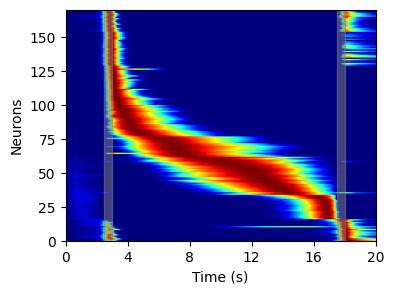

In [85]:
# Averge accross the batch
avg_hs = np.mean(hidden_states, axis=0)

# Plot the sorted hidden states
fig, ax = plt.subplots(figsize=(4, 3))
norm_hs, fig, ax, idx = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax, return_idx=True)
ax.axvspan(2.5, 3,   alpha=0.5, color='grey', zorder=0)
ax.axvspan(17.5, 18, alpha=0.5, color='grey', zorder=0)
ax.set_xlabel('Time (s)')

print('The number of active neurons:', norm_hs.shape[1])
hidden_states_active = hidden_states[:, :, idx]

is_time_cell = time_analysis(hidden_states_active)
print('The number of time cells in the active neurons:', np.sum(is_time_cell))
